# GSE126836 - Human brain microglia pseudobulk projected into ARCHS4 and GTEx

**Environment:** `clamp-analyses`

Projects human substantia nigra single-nucleus RNA-seq data from GSE126836 into two existing CLAMP models:

- ARCHS4: `output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds`
- GTEx: `output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds`

**Dataset:** Welch et al. 2019, *Cell* 177:1873–1887: "Single-Cell Multi-Omic Integration Compares and Contrasts Features of Brain Cell Identity." Seven human substantia nigra donors (MD5534, MD5828, MD5840, MD5862, MD5893, MD6060, MD6063), 10X Chromium V2, ~44 k nuclei.

**Cell type annotations:** The GEO supplementary files (GSE126836) contain only raw count matrices; no per-barcode annotations are distributed there. The author-processed LIGER object with cluster assignments is hosted on the **Broad Institute Single Cell Portal** at [SCP466](https://singlecell.broadinstitute.org/single_cell/study/SCP466) (login required). To use the official labels, download the cell metadata from SCP466, format it as a CSV with columns `barcode`, `cell_type`, `donor`, and place it at:

```
output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_cell_annotations.csv
```

If that file is present the notebook uses it; otherwise it falls back to marker-module scoring. Microglia assignment is reliable under the fallback (CX3CR1, P2RY12, TMEM119 are highly specific), but neuron subtype assignments should be treated as approximate.

**Biological question:** Can the ARCHS4 model capture microglia-specific brain cell-state programs more directly than the GTEx model? Key contrast: microglia vs all other brain cell types (pseudobulked by donor × cell_type).

**Target ARCHS4 annotations:**
- `C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA`
- `C8_ZHONG_PFC_MAJOR_TYPES_MICROGLIA`

These are present in the ARCHS4 model and absent as exact annotations in the GTEx model.

## Libraries

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(here)
  library(CLAMP)
  library(Matrix)
  library(ggplot2)
  library(ggrepel)
  library(limma)
})

## Paths and thresholds

In [2]:
out_dir         <- here("output", "03_model_biology", "00_archs4", "03_tissue_projections", "04_human_brain_microglia_GSE126836")
data_dir        <- file.path(out_dir, "data")
projection_dir  <- file.path(out_dir, "projections")
results_dir     <- file.path(out_dir, "results")
figure_dir      <- file.path(out_dir, "figures")

for (dir_i in c(data_dir, projection_dir, results_dir, figure_dir)) {
  dir.create(dir_i, recursive = TRUE, showWarnings = FALSE)
}

GEO_ACCESSION <- "GSE126836"
GEO_SUPPL_URL <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE126nnn/GSE126836/suppl"
SN_SAMPLE_IDS <- c("MD5534", "MD5828", "MD5840", "MD5862", "MD5893", "MD6060", "MD6063")

LV_FDR_CUTOFF <- 0.05
LV_LOGFC_CUTOFF <- 0.10
PATHWAY_FDR_CUTOFF <- 0.05
PATHWAY_AUC_CUTOFF <- 0.70

MIN_UMIS <- 500
MIN_GENES <- 300
MIN_CELLS_PER_PSEUDOBULK <- 20
MIN_MARKER_SCORE <- 0.05
MIN_MARKER_MARGIN <- 0.02

archs4_microglia_pathways <- c(
  "C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA",
  "C8_ZHONG_PFC_MAJOR_TYPES_MICROGLIA"
)

broad_gtex_pattern <- paste(
  c("BRAIN", "GLIA", "ASTRO", "OLIGO", "MICROGLIA", "CORTEX", "PFC",
    "NEURON", "IMMUNE", "MYELOID", "MACROPHAGE"),
  collapse = "|"
)

model_paths <- list(
  ARCHS4 = here("output", "01_model_building", "04_archs4", "06_bp_coverage_rshall", "06_bp_coverage_hall_rs_100", "hall_coverage_rs100_seed_1", "CLAMPfull_hall.rds"),
  GTEx   = here("output", "01_model_building", "02_gtex", "10_CLAMP_hall", "CLAMPfull_hall.rds")
)

list(out_dir = out_dir, models = model_paths)

$out_dir
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836"

$models
$models$ARCHS4
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds"

$models$GTEx
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds"

## General helpers

In [3]:
clean_pathway <- function(x) {
  x <- ifelse(is.na(x) | x == "", "unannotated", x)
  x <- gsub("^HALL_HALLMARK_", "", x)
  x <- gsub("^HALLMARK_", "", x)
  x <- gsub("^REACTOME_REACTOME_", "", x)
  x <- gsub("^REACTOME_", "", x)
  x <- gsub("^GOBP_GOBP_|^GOCC_GOCC_|^GOMF_GOMF_", "", x)
  x <- gsub("^GOBP_|^GOCC_|^GOMF_", "", x)
  x <- gsub("^C[0-9]+_", "", x)
  x <- gsub("_", " ", x)
  trimws(gsub("\\s+", " ", x))
}

wrap_label <- function(x, width = 45) {
  vapply(
    x,
    function(s) paste(strwrap(s, width = width), collapse = "\n"),
    character(1),
    USE.NAMES = FALSE
  )
}

empty_plot <- function(label) {
  ggplot() +
    theme_void() +
    annotate("text", x = 0.5, y = 0.5, label = label,
             size = 4, colour = "grey55", hjust = 0.5)
}

sanitize_label <- function(x) {
  x <- gsub("[^A-Za-z0-9]+", "_", x)
  gsub("(^_+|_+$)", "", x)
}

standardize_cell_type <- function(x) {
  x0 <- tolower(trimws(x))
  dplyr::case_when(
    is.na(x0) | x0 == "" ~ NA_character_,
    grepl("micro", x0) ~ "Microglia",
    grepl("dopamin|dopamine|th_pos|tyrosine hydroxylase", x0) ~ "Dopaminergic neuron",
    grepl("inhib|gaba|gad", x0) ~ "Inhibitory neuron",
    grepl("excit|glut|slc17a", x0) ~ "Excitatory neuron",
    grepl("astro", x0) ~ "Astrocyte",
    grepl("opc|precursor", x0) ~ "OPC",
    grepl("oligo", x0) ~ "Oligodendrocyte",
    grepl("endo|vascular|pericyte|mural", x0) ~ "Vascular",
    grepl("neur", x0) ~ "Neuron",
    TRUE ~ x
  )
}

cell_type_palette <- c(
  "Microglia" = "#D95F0E",
  "Astrocyte" = "#1B9E77",
  "Oligodendrocyte" = "#7570B3",
  "OPC" = "#E7298A",
  "Excitatory neuron" = "#66A61E",
  "Inhibitory neuron" = "#E6AB02",
  "Dopaminergic neuron" = "#A6761D",
  "Neuron" = "#666666",
  "Vascular" = "#1F78B4",
  "Unassigned" = "grey70"
)

condition_palette <- c(
  "Microglia" = "#D95F0E",
  "NonMicroglia" = "#2C7FB8"
)

## Download GSE126836 substantia nigra matrices

In [4]:
geo_file_name <- function(sample_id, file_type = c("barcodes", "genes", "matrix")) {
  file_type <- match.arg(file_type)
  suffix <- switch(
    file_type,
    barcodes = "barcodes.csv.gz",
    genes = "genes.csv.gz",
    matrix = "matrix.mtx.gz"
  )
  paste0("GSE126836_SN_", sample_id, "_", suffix)
}

download_geo_file <- function(file_name) {
  dest <- file.path(data_dir, file_name)
  if (!file.exists(dest)) {
    download.file(file.path(GEO_SUPPL_URL, file_name), dest, mode = "wb", quiet = FALSE)
  } else {
    message("Using cached file: ", basename(dest))
  }
  dest
}

expected_files <- unlist(lapply(SN_SAMPLE_IDS, function(sample_id) {
  vapply(c("barcodes", "genes", "matrix"), function(type) geo_file_name(sample_id, type), character(1))
}), use.names = FALSE)

local_files <- vapply(expected_files, download_geo_file, character(1))
file.info(local_files)[, c("size", "mtime")]

Using cached file: GSE126836_SN_MD5534_barcodes.csv.gz



Using cached file: GSE126836_SN_MD5534_genes.csv.gz



Using cached file: GSE126836_SN_MD5534_matrix.mtx.gz



Using cached file: GSE126836_SN_MD5828_barcodes.csv.gz



Using cached file: GSE126836_SN_MD5828_genes.csv.gz



...

Using cached file: GSE126836_SN_MD6060_matrix.mtx.gz



Using cached file: GSE126836_SN_MD6063_barcodes.csv.gz



Using cached file: GSE126836_SN_MD6063_genes.csv.gz



Using cached file: GSE126836_SN_MD6063_matrix.mtx.gz



,size,mtime
,<dbl>,<dttm>
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5534_barcodes.csv.gz,54983,2026-05-01 23:07:31
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5534_genes.csv.gz,85957,2026-05-01 23:07:32
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5534_matrix.mtx.gz,35670068,2026-05-01 23:07:34
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5828_barcodes.csv.gz,9005,2026-05-01 23:07:35
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5828_genes.csv.gz,85957,2026-05-01 23:07:35
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5828_matrix.mtx.gz,5514870,2026-05-01 23:07:36
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5840_barcodes.csv.gz,26180,2026-05-01 23:07:37
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5840_genes.csv.gz,85957,2026-05-01 23:07:37
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/brain_microglia_GSE126836/data/GSE126836_SN_MD5840_matrix.mtx.gz,18831884,2026-05-01 23:07:39


## Cell annotation and pseudobulk helpers

In [5]:
marker_sets <- list(
  "Microglia" = c("CX3CR1", "P2RY12", "TMEM119", "AIF1", "C1QA", "C1QB", "C1QC", "TYROBP", "CSF1R", "TREM2"),
  "Astrocyte" = c("AQP4", "GFAP", "ALDH1L1", "SLC1A2", "SLC1A3", "GJA1", "SOX9"),
  "Oligodendrocyte" = c("MBP", "PLP1", "MOG", "MOBP", "MAG", "CLDN11"),
  "OPC" = c("PDGFRA", "CSPG4", "VCAN", "OLIG1", "OLIG2"),
  "Excitatory neuron" = c("SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "TBR1"),
  "Inhibitory neuron" = c("GAD1", "GAD2", "SLC6A1", "DLX1", "DLX2"),
  "Dopaminergic neuron" = c("TH", "SLC6A3", "SLC18A2", "DDC", "NR4A2"),
  "Vascular" = c("PECAM1", "CLDN5", "FLT1", "KDR", "RGS5", "PDGFRB", "COL1A1")
)

read_gzip_vector <- function(path) {
  read.csv(gzfile(path), stringsAsFactors = FALSE, check.names = FALSE)[[1]]
}

read_sn_count_matrix <- function(sample_id) {
  genes_path <- file.path(data_dir, geo_file_name(sample_id, "genes"))
  barcodes_path <- file.path(data_dir, geo_file_name(sample_id, "barcodes"))
  matrix_path <- file.path(data_dir, geo_file_name(sample_id, "matrix"))

  genes <- read_gzip_vector(genes_path)
  barcodes <- read_gzip_vector(barcodes_path)

  con <- gzfile(matrix_path)
  on.exit(try(close(con), silent = TRUE), add = TRUE)
  counts <- Matrix::readMM(con)
  counts <- as(counts, "CsparseMatrix")

  rownames(counts) <- genes
  colnames(counts) <- barcodes
  counts
}

score_marker_sets <- function(log_norm, marker_sets) {
  scores <- lapply(marker_sets, function(genes) {
    genes_i <- intersect(genes, rownames(log_norm))
    if (length(genes_i) == 0) {
      rep(NA_real_, ncol(log_norm))
    } else {
      Matrix::colMeans(log_norm[genes_i, , drop = FALSE])
    }
  })
  as.data.frame(scores, check.names = FALSE)
}

assign_marker_cell_types <- function(counts) {
  lib_size <- Matrix::colSums(counts)
  log_norm <- log1p(counts %*% Matrix::Diagonal(x = 1e4 / pmax(lib_size, 1)))
  marker_scores <- score_marker_sets(log_norm, marker_sets)
  score_mat <- as.matrix(marker_scores)

  best_idx <- max.col(score_mat, ties.method = "first")
  top_score <- score_mat[cbind(seq_len(nrow(score_mat)), best_idx)]
  second_score <- apply(score_mat, 1, function(v) sort(v, decreasing = TRUE, na.last = TRUE)[2])
  margin <- top_score - second_score

  cell_type <- colnames(score_mat)[best_idx]
  cell_type[top_score < MIN_MARKER_SCORE | margin < MIN_MARKER_MARGIN] <- "Unassigned"

  marker_scores$cell_type <- cell_type
  marker_scores$top_score <- top_score
  marker_scores$score_margin <- margin
  marker_scores
}

read_optional_annotations <- function(path) {
  if (!file.exists(path)) {
    message("No external annotation file found at ", path, "; using marker-module annotations.")
    return(NULL)
  }

  ann <- data.table::fread(path) %>% as.data.frame()
  names_lower <- tolower(names(ann))
  names(ann) <- names_lower

  barcode_col <- intersect(c("barcode", "cell", "cell_id", "cellid"), names(ann))[1]
  type_col <- intersect(c("cell_type", "celltype", "broad_cell_type", "annotation", "label", "cluster_label"), names(ann))[1]
  donor_col <- intersect(c("donor", "sample", "sample_id", "individual"), names(ann))[1]

  stopifnot(!is.na(barcode_col), !is.na(type_col))

  out <- ann[, c(barcode_col, type_col, donor_col), drop = FALSE]
  names(out) <- c("barcode", "cell_type", ifelse(is.na(donor_col), "drop", "donor"))[seq_along(out)]
  if ("drop" %in% names(out)) out$drop <- NULL
  if (!"donor" %in% names(out)) out$donor <- sub("^([A-Za-z]+[0-9]+).*$", "\\1", out$barcode)
  out$cell_type <- standardize_cell_type(out$cell_type)
  out
}

annotate_nuclei <- function(counts, sample_id, external_annotations = NULL) {
  qc <- data.frame(
    barcode = colnames(counts),
    donor = sample_id,
    n_umis = as.numeric(Matrix::colSums(counts)),
    n_genes = as.numeric(Matrix::colSums(counts > 0)),
    stringsAsFactors = FALSE
  )

  keep <- qc$n_umis >= MIN_UMIS & qc$n_genes >= MIN_GENES
  counts <- counts[, keep, drop = FALSE]
  qc <- qc[keep, , drop = FALSE]

  if (!is.null(external_annotations)) {
    ann_i <- external_annotations %>%
      dplyr::filter(donor == sample_id | grepl(sample_id, barcode, fixed = TRUE)) %>%
      dplyr::select(barcode, cell_type)
    qc <- qc %>% dplyr::left_join(ann_i, by = "barcode")
    qc$annotation_source <- "external"
    qc$top_score <- NA_real_
    qc$score_margin <- NA_real_
  } else {
    marker_scores <- assign_marker_cell_types(counts)
    qc <- cbind(qc, marker_scores)
    qc$annotation_source <- "marker_modules"
  }

  qc$cell_type <- ifelse(is.na(qc$cell_type) | qc$cell_type == "", "Unassigned", qc$cell_type)
  list(counts = counts, meta = qc)
}

collapse_duplicate_rows <- function(mat) {
  if (!anyDuplicated(rownames(mat))) return(mat)
  rowsum(as.matrix(mat), group = rownames(mat), reorder = FALSE)
}

## Build donor x cell_type pseudobulk matrix

In [ ]:
cell_meta_path <- file.path(data_dir, "GSE126836_SN_cell_metadata.csv")
pseudobulk_counts_path <- file.path(data_dir, "GSE126836_SN_pseudobulk_counts.rds")
pseudobulk_meta_path <- file.path(data_dir, "GSE126836_SN_pseudobulk_metadata.csv")
annotation_path <- file.path(data_dir, "GSE126836_cell_annotations.csv")

if (!file.exists(annotation_path)) {
  message(
    "\n[INFO] No author annotation file found at:\n  ", annotation_path,
    "\nFalling back to marker-module cell type scoring.",
    "\nTo use the official Welch et al. 2019 cluster labels instead:",
    "\n  1. Log in to https://singlecell.broadinstitute.org/single_cell/study/SCP466",
    "\n  2. Download the cell metadata file from the study.",
    "\n  3. Reformat it as a CSV with columns: barcode, cell_type, donor",
    "\n  4. Save to: ", annotation_path,
    "\n  5. Delete the cached pseudobulk files (pseudobulk_counts.rds, pseudobulk_metadata.csv)",
    "\n     so the annotation is re-applied on next run.\n"
  )
}

if (!file.exists(pseudobulk_counts_path) || !file.exists(pseudobulk_meta_path) || !file.exists(cell_meta_path)) {
  external_annotations <- read_optional_annotations(annotation_path)
  pb_list <- list()
  pb_meta_list <- list()
  cell_meta_list <- list()

  for (sample_id in SN_SAMPLE_IDS) {
    message("Processing ", sample_id)
    counts_i <- read_sn_count_matrix(sample_id)
    ann_i <- annotate_nuclei(counts_i, sample_id, external_annotations)
    counts_i <- ann_i$counts
    meta_i <- ann_i$meta

    cell_meta_list[[sample_id]] <- meta_i

    ct_counts <- meta_i %>%
      dplyr::filter(cell_type != "Unassigned") %>%
      dplyr::count(cell_type, name = "n_cells") %>%
      dplyr::filter(n_cells >= MIN_CELLS_PER_PSEUDOBULK) %>%
      dplyr::arrange(cell_type)

    for (ct in ct_counts$cell_type) {
      cells <- meta_i$barcode[meta_i$cell_type == ct]
      sample_name <- paste(sample_id, sanitize_label(ct), sep = "__")
      pb_list[[sample_name]] <- as.numeric(Matrix::rowSums(counts_i[, cells, drop = FALSE]))
      names(pb_list[[sample_name]]) <- rownames(counts_i)
      pb_meta_list[[sample_name]] <- data.frame(
        sample = sample_name,
        donor = sample_id,
        cell_type = ct,
        condition = ifelse(ct == "Microglia", "Microglia", "NonMicroglia"),
        n_cells = length(cells),
        stringsAsFactors = FALSE
      )
    }

    rm(counts_i, ann_i, meta_i)
    gc()
  }

  meta_cell <- dplyr::bind_rows(cell_meta_list)
  counts_pb <- do.call(cbind, pb_list)
  counts_pb <- collapse_duplicate_rows(counts_pb)
  storage.mode(counts_pb) <- "numeric"
  meta_pb <- dplyr::bind_rows(pb_meta_list)

  stopifnot(all(colnames(counts_pb) == meta_pb$sample))

  contrast_donors <- meta_pb %>%
    dplyr::distinct(donor, condition) %>%
    dplyr::group_by(donor) %>%
    dplyr::summarise(
      has_microglia = any(condition == "Microglia"),
      has_non_microglia = any(condition == "NonMicroglia"),
      .groups = "drop"
    ) %>%
    dplyr::filter(has_microglia, has_non_microglia) %>%
    dplyr::pull(donor)

  if (length(contrast_donors) < 3) {
    stop("Fewer than three donors have both microglia and non-microglia pseudobulk samples.")
  }

  meta_pb <- meta_pb %>% dplyr::filter(donor %in% contrast_donors)
  counts_pb <- counts_pb[, meta_pb$sample, drop = FALSE]

  saveRDS(counts_pb, pseudobulk_counts_path)
  data.table::fwrite(meta_cell, cell_meta_path)
  data.table::fwrite(meta_pb, pseudobulk_meta_path)
} else {
  counts_pb <- readRDS(pseudobulk_counts_path)
  meta_cell <- data.table::fread(cell_meta_path) %>% as.data.frame()
  meta_pb <- data.table::fread(pseudobulk_meta_path) %>% as.data.frame()
}

annotation_source <- if (file.exists(annotation_path)) "SCP466 / author-provided" else "marker-module scoring (fallback)"
cat("Annotation source:", annotation_source, "\n")
cat("Cell metadata:", nrow(meta_cell), "nuclei\n")
cat("Pseudobulk matrix:", nrow(counts_pb), "genes x", ncol(counts_pb), "samples\n")
print(table(meta_pb$donor, meta_pb$condition))
meta_pb %>% dplyr::count(cell_type, condition, name = "n_pseudobulk") %>% dplyr::arrange(condition, cell_type)

## Normalize pseudobulk matrix for CLAMP projection

In [7]:
norm_path <- file.path(data_dir, "GSE126836_SN_pseudobulk_norm_clamp.rds")

if (!file.exists(norm_path)) {
  counts_pb <- counts_pb[rowSums(counts_pb) > 0, , drop = FALSE]
  cpm_pb <- cpmCLAMP(counts_pb)
  prep_pb <- preprocessCLAMP(Y = cpm_pb, mean_cutoff = 0.5, var_cutoff = 0.1)
  norm_pb <- zscoreCLAMP(Y_filtered = prep_pb$Y_filtered,
                         rowStats = prep_pb$rowStats)
  saveRDS(norm_pb, norm_path)
} else {
  norm_pb <- readRDS(norm_path)
}

cat("Normalized pseudobulk matrix:", nrow(norm_pb), "genes x", ncol(norm_pb), "samples
")

Normalized pseudobulk matrix: 22875 genes x 42 samples


## Load projection models

In [8]:
read_projection_model <- function(path) {
  mdl <- readRDS(path)
  keep <- list(
    Z = as.matrix(mdl$Z),
    L2 = mdl$L2,
    summary = mdl$summary
  )
  rm(mdl)
  gc()
  keep
}

models <- lapply(model_paths, read_projection_model)

for (model_name in names(models)) {
  mdl <- models[[model_name]]
  n_sig <- sum(mdl$summary$FDR < PATHWAY_FDR_CUTOFF &
                 mdl$summary$AUC > PATHWAY_AUC_CUTOFF,
               na.rm = TRUE)
  cat(model_name, "model - genes:", nrow(mdl$Z),
      "| LVs:", ncol(mdl$Z),
      "| significant pathway annotations:", n_sig, "
")
}

archs4_exact_target_check <- as.data.frame(models$ARCHS4$summary) %>%
  dplyr::filter(pathway %in% archs4_microglia_pathways) %>%
  dplyr::mutate(AUC = as.numeric(AUC), FDR = as.numeric(FDR)) %>%
  dplyr::arrange(pathway, dplyr::desc(AUC), FDR)

gtex_exact_target_check <- as.data.frame(models$GTEx$summary) %>%
  dplyr::filter(pathway %in% archs4_microglia_pathways) %>%
  dplyr::mutate(AUC = as.numeric(AUC), FDR = as.numeric(FDR)) %>%
  dplyr::arrange(pathway, dplyr::desc(AUC), FDR)

cat("ARCHS4 exact target annotations:", nrow(archs4_exact_target_check), "
")
cat("GTEx exact target annotations:", nrow(gtex_exact_target_check), "
")
archs4_exact_target_check %>% dplyr::select(LV, pathway, AUC, FDR)

ARCHS4 model - genes: 18423 | LVs: 1728 | significant pathway annotations: 1794 
GTEx model - genes: 21613 | LVs: 578 | significant pathway annotations: 886 


ARCHS4 exact target annotations: 2 


GTEx exact target annotations: 0 


,LV,pathway,AUC,FDR
,<chr>,<chr>,<dbl>,<dbl>
C8376,LV1653,C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA,0.9772012,2.355322e-45
C8864,LV1653,C8_ZHONG_PFC_MAJOR_TYPES_MICROGLIA,0.9602333,8.340766e-50


## Projection and contrast helpers

In [9]:
build_lv_annot <- function(mdl,
                           pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                           auc_cutoff = PATHWAY_AUC_CUTOFF) {
  mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), FDR, .by_group = TRUE) %>%
    dplyr::summarise(
      pathways = paste(clean_pathway(pathway), collapse = " | "),
      top_AUC  = max(AUC, na.rm = TRUE),
      n_paths  = dplyr::n(),
      .groups  = "drop"
    )
}

project_model <- function(mdl, norm_mat, model_name) {
  common <- intersect(rownames(mdl$Z), rownames(norm_mat))
  mdl_sub <- list(
    Z = mdl$Z[common, , drop = FALSE],
    L2 = mdl$L2
  )
  B <- projectCLAMP(CLAMPres = mdl_sub,
                    newdata = norm_mat[common, , drop = FALSE])
  cat(model_name, "common genes:", length(common),
      sprintf("(%.1f%% of model genes)
", 100 * length(common) / nrow(mdl$Z)))
  B
}

rank_lvs_microglia <- function(B, meta, mdl, model_name) {
  meta_aligned <- meta[match(colnames(B), meta$sample), , drop = FALSE]
  stopifnot(!any(is.na(meta_aligned$sample)))
  stopifnot(all(meta_aligned$sample == colnames(B)))

  meta_aligned$condition <- relevel(
    factor(meta_aligned$condition, levels = c("NonMicroglia", "Microglia")),
    ref = "NonMicroglia"
  )
  donor <- factor(meta_aligned$donor)
  design <- model.matrix(~ donor + condition, data = meta_aligned)
  colnames(design) <- make.names(colnames(design))

  coef_name <- "conditionMicroglia"
  stopifnot(coef_name %in% colnames(design))

  fit <- lmFit(B, design)
  fit <- eBayes(fit)
  de <- topTable(fit, coef = coef_name, n = Inf,
                 adjust.method = "BH", sort.by = "P")
  de$LV <- rownames(de)

  annot <- build_lv_annot(mdl)
  de %>%
    dplyr::left_join(annot, by = "LV") %>%
    dplyr::mutate(
      model = model_name,
      pathways = ifelse(is.na(pathways), "unannotated", pathways),
      top_AUC = ifelse(is.na(top_AUC), 0, top_AUC),
      n_paths = ifelse(is.na(n_paths), 0L, as.integer(n_paths)),
      abs_logFC = abs(logFC),
      direction = dplyr::case_when(
        logFC > 0 ~ "Higher in Microglia",
        logFC < 0 ~ "Higher in Non-microglia",
        TRUE ~ "No shift"
      )
    ) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC))
}

extract_shifted_pathways <- function(lv_ranked, mdl, model_name,
                                     lv_fdr_cutoff = LV_FDR_CUTOFF,
                                     lfc_cutoff = LV_LOGFC_CUTOFF,
                                     pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                                     auc_cutoff = PATHWAY_AUC_CUTOFF) {
  annot <- mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::mutate(pathway_clean = clean_pathway(pathway))

  lv_ranked %>%
    dplyr::filter(adj.P.Val < lv_fdr_cutoff, abs_logFC >= lfc_cutoff) %>%
    dplyr::inner_join(annot, by = "LV") %>%
    dplyr::mutate(model = model_name) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC), dplyr::desc(AUC))
}

empty_pathway_summary <- function() {
  data.frame(
    model = character(),
    pathway_clean = character(),
    direction = character(),
    n_lvs = integer(),
    best_AUC = numeric(),
    min_pathway_FDR = numeric(),
    min_lv_FDR = numeric(),
    max_abs_logFC = numeric(),
    mean_logFC = numeric(),
    LVs = character(),
    stringsAsFactors = FALSE
  )
}

summarise_shifted_pathways <- function(pathway_hits) {
  if (nrow(pathway_hits) == 0) return(empty_pathway_summary())
  pathway_hits %>%
    dplyr::group_by(model, pathway_clean, direction) %>%
    dplyr::summarise(
      n_lvs = dplyr::n_distinct(LV),
      best_AUC = max(AUC, na.rm = TRUE),
      min_pathway_FDR = min(FDR, na.rm = TRUE),
      min_lv_FDR = min(adj.P.Val, na.rm = TRUE),
      max_abs_logFC = max(abs_logFC, na.rm = TRUE),
      mean_logFC = mean(logFC, na.rm = TRUE),
      LVs = paste(unique(LV), collapse = ", "),
      .groups = "drop"
    ) %>%
    dplyr::arrange(model, direction, dplyr::desc(max_abs_logFC), min_lv_FDR)
}

## Plot helpers

In [ ]:
make_pca_plot <- function(B, meta, title = NULL) {
  pca  <- prcomp(t(B), scale. = TRUE)
  vexp <- round(100 * summary(pca)$importance[2, 1:2], 1)
  df <- as.data.frame(pca$x[, 1:2])
  df$sample <- rownames(df)
  df <- df %>% dplyr::left_join(meta, by = "sample")

  ggplot(df, aes(PC1, PC2, color = cell_type, shape = condition, label = sample)) +
    geom_point(size = 3.2, alpha = 0.9) +
    ggrepel::geom_text_repel(size = 2.5, show.legend = FALSE, max.overlaps = 25) +
    scale_color_manual(values = cell_type_palette, na.value = "grey70") +
    scale_shape_manual(values = c(Microglia = 17, NonMicroglia = 16)) +
    labs(title = title,
         x = paste0("PC1 (", vexp[1], "%)"),
         y = paste0("PC2 (", vexp[2], "%)"),
         color = "Cell type",
         shape = NULL) +
    theme_bw(base_size = 12)
}

make_volcano <- function(lv_ranked,
                         fdr_cutoff = LV_FDR_CUTOFF,
                         lfc_cutoff = LV_LOGFC_CUTOFF,
                         label_top = 15,
                         title = NULL) {
  df <- lv_ranked %>%
    dplyr::mutate(
      sig = dplyr::case_when(
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC > 0 ~ "Higher in Microglia",
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC < 0 ~ "Higher in Non-microglia",
        TRUE ~ "not selected"
      ),
      neg_log10_fdr = pmin(-log10(pmax(adj.P.Val, .Machine$double.xmin)), 60)
    )

  top_ids <- df %>%
    dplyr::filter(sig != "not selected") %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val) %>%
    dplyr::slice_head(n = label_top) %>%
    dplyr::pull(LV)

  df$label <- ifelse(df$LV %in% top_ids, df$LV, NA_character_)

  ggplot(df, aes(logFC, neg_log10_fdr, color = sig)) +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "grey50") +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dotted", color = "grey40") +
    geom_point(alpha = 0.75, size = 1.8) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.8,
                             max.overlaps = 25, na.rm = TRUE,
                             show.legend = FALSE) +
    scale_color_manual(values = c(
      "Higher in Microglia" = "#D95F0E",
      "Higher in Non-microglia" = "#2C7FB8",
      "not selected" = "grey75"
    )) +
    labs(title = title,
         x = "log2 fold-change (microglia vs non-microglia)",
         y = "-log10(FDR)",
         color = NULL) +
    theme_bw(base_size = 12)
}

make_lv_score_plot <- function(B, meta, lv, model_name, lv_label = NULL, title = NULL) {
  if (is.na(lv) || !lv %in% rownames(B)) {
    return(empty_plot(paste(model_name, "no matching LV to plot")))
  }

  df <- data.frame(
    sample = colnames(B),
    score = as.numeric(B[lv, ]),
    stringsAsFactors = FALSE
  ) %>%
    dplyr::left_join(meta, by = "sample")

  cell_order <- df %>%
    dplyr::group_by(cell_type) %>%
    dplyr::summarise(median_score = median(score, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(median_score)) %>%
    dplyr::pull(cell_type)

  df$cell_type <- factor(df$cell_type, levels = cell_order)
  if (is.null(title)) title <- paste0(model_name, " ", lv)
  if (is.null(lv_label)) lv_label <- lv

  ggplot(df, aes(cell_type, score)) +
    geom_boxplot(aes(fill = condition), outlier.shape = NA,
                 alpha = 0.25, colour = "grey35", width = 0.65) +
    geom_point(aes(color = condition, shape = donor),
               position = position_jitter(width = 0.12, height = 0),
               size = 2.3, alpha = 0.9) +
    scale_fill_manual(values = condition_palette, name = NULL) +
    scale_color_manual(values = condition_palette, name = NULL) +
    labs(title = title,
         subtitle = wrap_label(lv_label, width = 80),
         x = NULL,
         y = "Projected LV score",
         shape = "Donor") +
    coord_flip() +
    theme_bw(base_size = 11) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 8, hjust = 0.5, color = "grey35"),
      axis.text.y = element_text(size = 9)
    )
}

make_pathway_shift_plot <- function(pathway_hits, model_name, top_n_per_direction = 12) {
  if (nrow(pathway_hits) == 0) {
    return(empty_plot(paste(model_name, "no annotated selected LVs")))
  }

  plot_df <- pathway_hits %>%
    dplyr::filter(model == model_name) %>%
    dplyr::group_by(direction) %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val, dplyr::desc(AUC), .by_group = TRUE) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      label = wrap_label(paste0(LV, " | ", toupper(pathway_clean)), width = 56),
      label = factor(label, levels = rev(unique(label))),
      neg_log10_lv_fdr = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    )

  if (nrow(plot_df) == 0) {
    return(empty_plot(paste(model_name, "no annotated selected LVs")))
  }

  x_lim <- max(abs(plot_df$logFC), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1

  ggplot(plot_df, aes(logFC, label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(aes(size = neg_log10_lv_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(values = c(
      "Higher in Microglia" = "#D95F0E",
      "Higher in Non-microglia" = "#2C7FB8"
    ), name = NULL) +
    scale_size_continuous(name = "-log10 LV FDR", range = c(2.5, 7.5)) +
    scale_x_continuous(limits = c(-x_lim, x_lim)) +
    labs(title = paste0(model_name, ": selected shifted pathways (microglia vs non-microglia)"),
         x = "log2 fold-change (microglia vs non-microglia)",
         y = NULL) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      axis.text.y = element_text(size = 7.5, lineheight = 0.9),
      legend.position = "right"
    )
}

## Project GSE126836 pseudobulks into ARCHS4 and GTEx

In [11]:
B_list <- lapply(names(models), function(model_name) {
  project_model(models[[model_name]], norm_pb, model_name)
})
names(B_list) <- names(models)

for (model_name in names(B_list)) {
  B <- B_list[[model_name]]
  write.csv(as.data.frame(B),
            file.path(projection_dir, paste0("GSE126836_SN_", model_name, "_projection.csv")),
            row.names = TRUE)
  cat(model_name, "projection:", nrow(B), "LVs x", ncol(B), "samples
")
}

ARCHS4 common genes: 14062 (76.3% of model genes)
GTEx common genes: 16505 (76.4% of model genes)


ARCHS4 projection: 1728 LVs x 42 samples
GTEx projection: 578 LVs x 42 samples


## PCA of projected LV scores

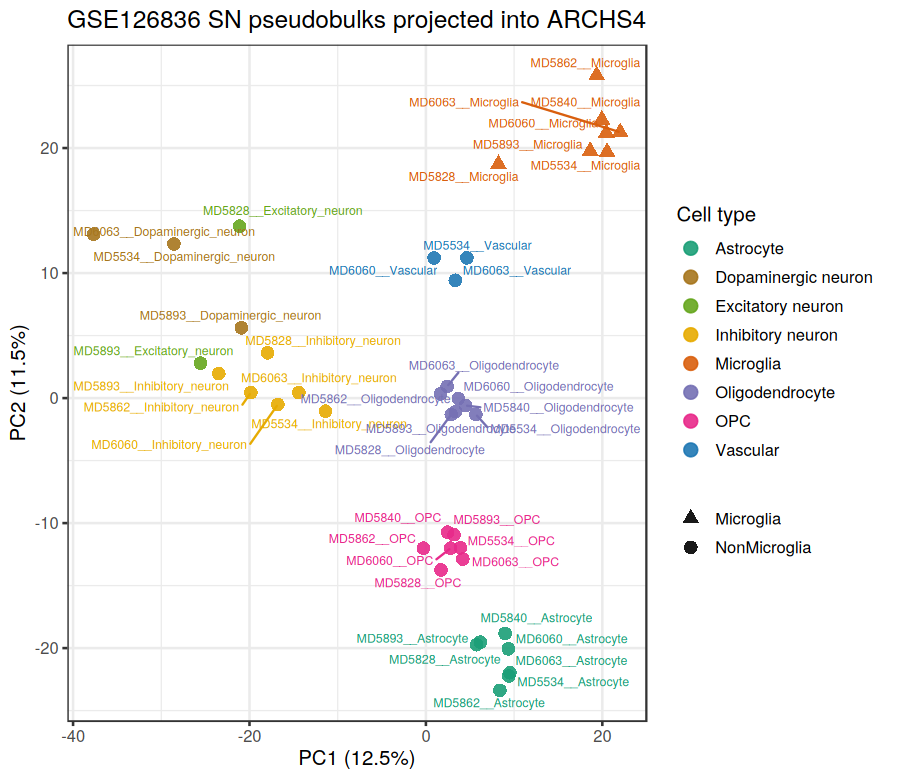

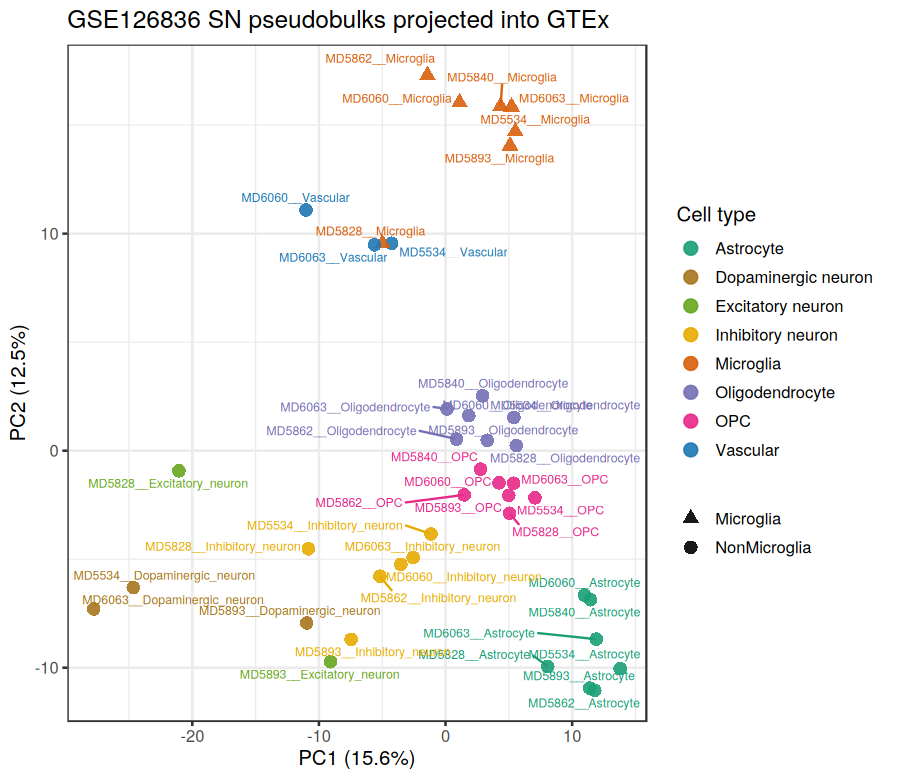

In [12]:
options(repr.plot.width = 7.5, repr.plot.height = 6.5)

for (model_name in names(B_list)) {
  p <- make_pca_plot(B_list[[model_name]], meta_pb,
                     title = paste0("GSE126836 SN pseudobulks projected into ", model_name))
  print(p)
  ggsave(file.path(figure_dir, paste0("pca_", model_name, ".png")),
         plot = p, width = 7.5, height = 6.5, dpi = 150)
}

## Microglia vs non-microglia contrasts on projected LV scores

In [13]:
ranked_lvs <- lapply(names(models), function(model_name) {
  rank_lvs_microglia(B = B_list[[model_name]],
                     meta = meta_pb,
                     mdl = models[[model_name]],
                     model_name = model_name)
})
names(ranked_lvs) <- names(models)

for (model_name in names(ranked_lvs)) {
  ranked_tbl <- ranked_lvs[[model_name]]
  write.csv(ranked_tbl,
            file.path(results_dir, paste0(model_name, "_microglia_vs_non_microglia_projected_LVs.csv")),
            row.names = FALSE)

  n_up <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC > 0)
  n_dn <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC < 0)
  cat(model_name, "selected LVs:",
      "higher in microglia =", n_up,
      "| higher in non-microglia =", n_dn, "
")
}

combined_ranked_lvs <- dplyr::bind_rows(ranked_lvs) %>%
  dplyr::arrange(model, adj.P.Val, dplyr::desc(abs_logFC))

selected_lvs <- combined_ranked_lvs %>%
  dplyr::filter(adj.P.Val < LV_FDR_CUTOFF, abs_logFC >= LV_LOGFC_CUTOFF) %>%
  dplyr::arrange(model, adj.P.Val, dplyr::desc(abs_logFC))

write.csv(combined_ranked_lvs,
          file.path(results_dir, "microglia_vs_non_microglia_projected_LVs_ARCHS4_and_GTEx.csv"),
          row.names = FALSE)
write.csv(selected_lvs,
          file.path(results_dir, "selected_microglia_vs_non_microglia_projected_LVs_ARCHS4_and_GTEx.csv"),
          row.names = FALSE)

selected_lvs %>%
  dplyr::select(model, LV, logFC, adj.P.Val, direction, top_AUC, n_paths, pathways) %>%
  dplyr::group_by(model) %>%
  dplyr::slice_head(n = 20)

ARCHS4 selected LVs: higher in microglia = 10 | higher in non-microglia = 3 
GTEx selected LVs: higher in microglia = 27 | higher in non-microglia = 23 


model,LV,logFC,adj.P.Val,direction,top_AUC,n_paths,pathways
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>
ARCHS4,LV1702,0.2152521,1.056526e-16,Higher in Microglia,0.8842625,6,TRAVAGLINI LUNG NONCLASSICAL MONOCYTE CELL | TRAVAGLINI LUNG CLASSICAL MONOCYTE CELL | AIZARANI LIVER C23 KUPFFER CELLS 3 | HAY BONE MARROW NEUTROPHIL | HAY BONE MARROW IMMATURE NEUTROPHIL | AIZARANI LIVER C18 NK NKT CELLS 5
ARCHS4,LV932,0.2036945,1.570435e-16,Higher in Microglia,0.0000000,0,unannotated
ARCHS4,LV883,0.1447832,5.649627e-14,Higher in Microglia,0.9883991,3,INTERLEUKIN 2 SIGNALING | FAN EMBRYONIC CTX BIG GROUPS BRAIN IMMUNE | CUI DEVELOPING HEART C9 B T CELL
ARCHS4,LV12,0.1065017,1.087697e-11,Higher in Microglia,0.9950969,8,HE LIM SUN FETAL LUNG C2 NEUTROPHIL CELL | DURANTE ADULT OLFACTORY NEUROEPITHELIUM DENDRITIC CELLS | HE LIM SUN FETAL LUNG C2 S100A12 HI CLASSICAL MONOCYTE | AIZARANI LIVER C23 KUPFFER CELLS 3 | TRAVAGLINI LUNG CLASSICAL MONOCYTE CELL | AIZARANI LIVER C18 NK NKT CELLS 5 | CUI DEVELOPING HEART C8 MACROPHAGE | HAY BONE MARROW NEUTROPHIL
ARCHS4,LV1672,0.1270770,4.271855e-11,Higher in Microglia,0.7404798,1,DESCARTES MAIN FETAL PHOTORECEPTOR CELLS
ARCHS4,LV1018,0.1181634,1.195446e-10,Higher in Microglia,0.9826642,3,TETRASPANIN ENRICHED MICRODOMAIN | SEMAPHORIN RECEPTOR COMPLEX | HE LIM SUN FETAL LUNG C2 SPP1 POS MACROPHAGE CELL
ARCHS4,LV1530,0.2548179,3.490730e-08,Higher in Microglia,0.0000000,0,unannotated
ARCHS4,LV1086,0.1162881,1.567904e-06,Higher in Microglia,0.9826785,1,HAY BONE MARROW CD34 POS ERP EARLY
ARCHS4,LV473,-0.1243353,5.112970e-04,Higher in Non-microglia,0.9999635,5,MKS COMPLEX | INTRACILIARY TRANSPORT PARTICLE B | INTRACILIARY TRANSPORT PARTICLE | CILIARY BASE | CILIARY TRANSITION ZONE


### Volcano plots

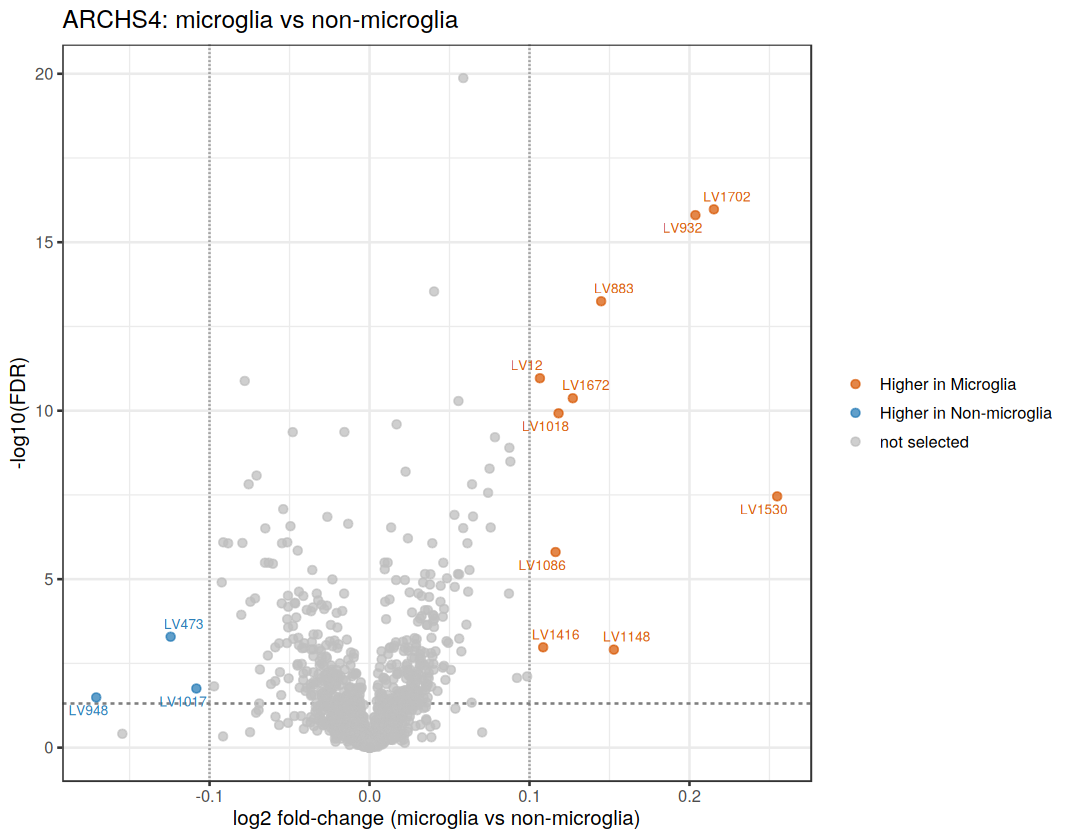

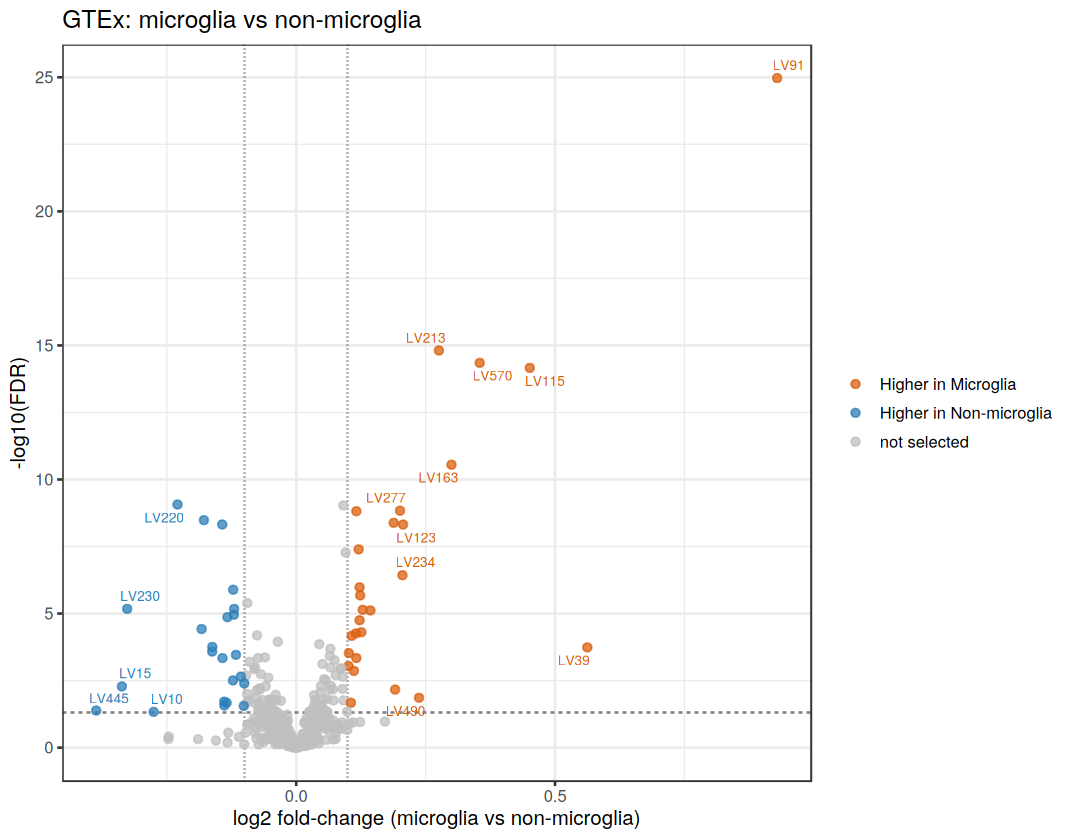

In [14]:
options(repr.plot.width = 9, repr.plot.height = 7)

for (model_name in names(ranked_lvs)) {
  p <- make_volcano(ranked_lvs[[model_name]],
                    title = paste0(model_name, ": microglia vs non-microglia"))
  print(p)
  ggsave(file.path(figure_dir, paste0("volcano_", model_name, ".png")),
         plot = p, width = 9, height = 7, dpi = 150)
}

## Target ARCHS4 microglia pathway LVs

In [15]:
archs4_target_annotations <- as.data.frame(models$ARCHS4$summary) %>%
  dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
  dplyr::filter(pathway %in% archs4_microglia_pathways) %>%
  dplyr::mutate(
    pathway_clean = clean_pathway(pathway),
    passes_pathway_threshold = FDR < PATHWAY_FDR_CUTOFF & AUC > PATHWAY_AUC_CUTOFF
  )

target_archs4_microglia_hits <- archs4_target_annotations %>%
  dplyr::left_join(
    ranked_lvs$ARCHS4 %>%
      dplyr::select(LV, logFC, AveExpr, t, P.Value, adj.P.Val, B,
                    abs_logFC, direction, model_pathways = pathways,
                    top_AUC, n_paths),
    by = "LV"
  ) %>%
  dplyr::mutate(
    model = "ARCHS4",
    selected_projected_lv = adj.P.Val < LV_FDR_CUTOFF & abs_logFC >= LV_LOGFC_CUTOFF,
    expected_microglia_enriched = logFC > 0
  ) %>%
  dplyr::arrange(!expected_microglia_enriched, adj.P.Val, dplyr::desc(AUC))

write.csv(target_archs4_microglia_hits,
          file.path(results_dir, "ARCHS4_target_microglia_pathway_LV_hits.csv"),
          row.names = FALSE)
write.csv(gtex_exact_target_check,
          file.path(results_dir, "GTEx_exact_target_microglia_pathway_check.csv"),
          row.names = FALSE)

cat("ARCHS4 target LV rows:", nrow(target_archs4_microglia_hits), "
")
cat("GTEx exact target LV rows:", nrow(gtex_exact_target_check), "
")

target_archs4_microglia_hits %>%
  dplyr::select(model, LV, pathway, AUC, FDR, logFC, adj.P.Val,
                direction, selected_projected_lv, expected_microglia_enriched)

ARCHS4 target LV rows: 2 


GTEx exact target LV rows: 0 


model,LV,pathway,AUC,FDR,logFC,adj.P.Val,direction,selected_projected_lv,expected_microglia_enriched
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
ARCHS4,LV1653,C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA,0.9772012,2.355322e-45,0.05859577,1.343644e-20,Higher in Microglia,FALSE,TRUE
ARCHS4,LV1653,C8_ZHONG_PFC_MAJOR_TYPES_MICROGLIA,0.9602333,8.340766e-50,0.05859577,1.343644e-20,Higher in Microglia,FALSE,TRUE


## Top ARCHS4 microglia LV across cell types

Warning message:
“The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 7 values. Consider specifying shapes manually if you need
  that many of them.”


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 7 values. Consider specifying shapes manually if you need
  that many of them.”


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


,pathway,LV,AUC,p_value,FDR,npos,nneg,pathway_clean,passes_pathway_threshold,logFC,⋯,adj.P.Val,B,abs_logFC,direction,model_pathways,top_AUC,n_paths,model,selected_projected_lv,expected_microglia_enriched
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<lgl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>,<lgl>,<lgl>
1,C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA,LV1653,0.9772012,2.752884e-48,2.355322e-45,72,17429,FAN EMBRYONIC CTX BIG GROUPS MICROGLIA,TRUE,0.05859577,⋯,1.343644e-20,44.34672,0.05859577,Higher in Microglia,DESCARTES MAIN FETAL MICROGLIA | DESCARTES FETAL EYE MICROGLIA | FAN EMBRYONIC CTX BIG GROUPS MICROGLIA | ZHONG PFC MAJOR TYPES MICROGLIA | DESCARTES FETAL CEREBRUM MICROGLIA | DESCARTES FETAL CEREBELLUM MICROGLIA | DESCARTES FETAL ADRENAL MYELOID CELLS | HU FETAL RETINA MICROGLIA,0.9861746,8,ARCHS4,FALSE,TRUE


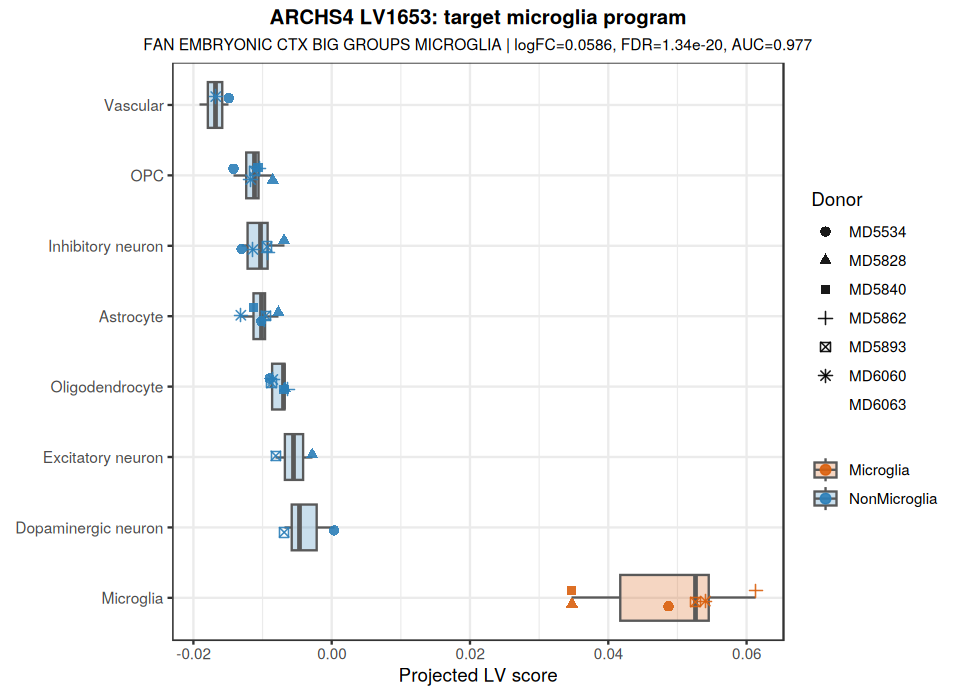

In [16]:
choose_top_archs4_microglia_lv <- function(target_tbl) {
  preferred <- target_tbl %>%
    dplyr::filter(expected_microglia_enriched, passes_pathway_threshold) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(AUC), dplyr::desc(logFC))
  if (nrow(preferred) > 0) return(preferred[1, , drop = FALSE])

  fallback <- target_tbl %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(AUC), dplyr::desc(logFC))
  if (nrow(fallback) == 0) return(data.frame())
  fallback[1, , drop = FALSE]
}

top_archs4_microglia <- choose_top_archs4_microglia_lv(target_archs4_microglia_hits)

top_archs4_lv <- if (nrow(top_archs4_microglia) == 0) NA_character_ else top_archs4_microglia$LV[1]
top_archs4_label <- if (nrow(top_archs4_microglia) == 0) {
  "No ARCHS4 target microglia LV found"
} else {
  paste0(top_archs4_microglia$pathway_clean[1],
         " | logFC=", signif(top_archs4_microglia$logFC[1], 3),
         ", FDR=", signif(top_archs4_microglia$adj.P.Val[1], 3),
         ", AUC=", signif(top_archs4_microglia$AUC[1], 3))
}

options(repr.plot.width = 8, repr.plot.height = 5.8)
p_archs4_microglia <- make_lv_score_plot(
  B = B_list$ARCHS4,
  meta = meta_pb,
  lv = top_archs4_lv,
  model_name = "ARCHS4",
  lv_label = top_archs4_label,
  title = paste0("ARCHS4 ", top_archs4_lv, ": target microglia program")
)
print(p_archs4_microglia)
ggsave(file.path(figure_dir, "top_ARCHS4_microglia_LV_scores_by_cell_type.png"),
       plot = p_archs4_microglia, width = 8, height = 5.8, dpi = 150)

top_archs4_microglia

## Matched GTEx brain/glial LV candidate

Warning message:
“The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 7 values. Consider specifying shapes manually if you need
  that many of them.”


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 7 values. Consider specifying shapes manually if you need
  that many of them.”


Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


LV,pathway,relevance_group,AUC,FDR,logFC,adj.P.Val,direction,selected_projected_lv,expected_microglia_enriched
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
LV91,C8_FAN_EMBRYONIC_CTX_MICROGLIA_3,microglia-like annotation,0.9908904,1.673270e-03,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_MAIN_FETAL_MICROGLIA,microglia-like annotation,0.9627209,4.382719e-16,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_FETAL_EYE_MICROGLIA,microglia-like annotation,0.9266338,2.534242e-14,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_FETAL_CEREBRUM_MICROGLIA,microglia-like annotation,0.9242284,6.708382e-38,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_HU_FETAL_RETINA_MICROGLIA,microglia-like annotation,0.9010200,1.588516e-33,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_FETAL_CEREBELLUM_MICROGLIA,microglia-like annotation,0.8977828,5.112689e-45,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_FETAL_STOMACH_MYELOID_CELLS,immune/myeloid annotation,0.9645787,3.527042e-09,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DESCARTES_FETAL_ADRENAL_MYELOID_CELLS,immune/myeloid annotation,0.9388778,3.654163e-17,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE
LV91,C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_MACROPHAGES,immune/myeloid annotation,0.9289998,5.670554e-09,0.9292323,1.068860e-25,Higher in Microglia,TRUE,TRUE


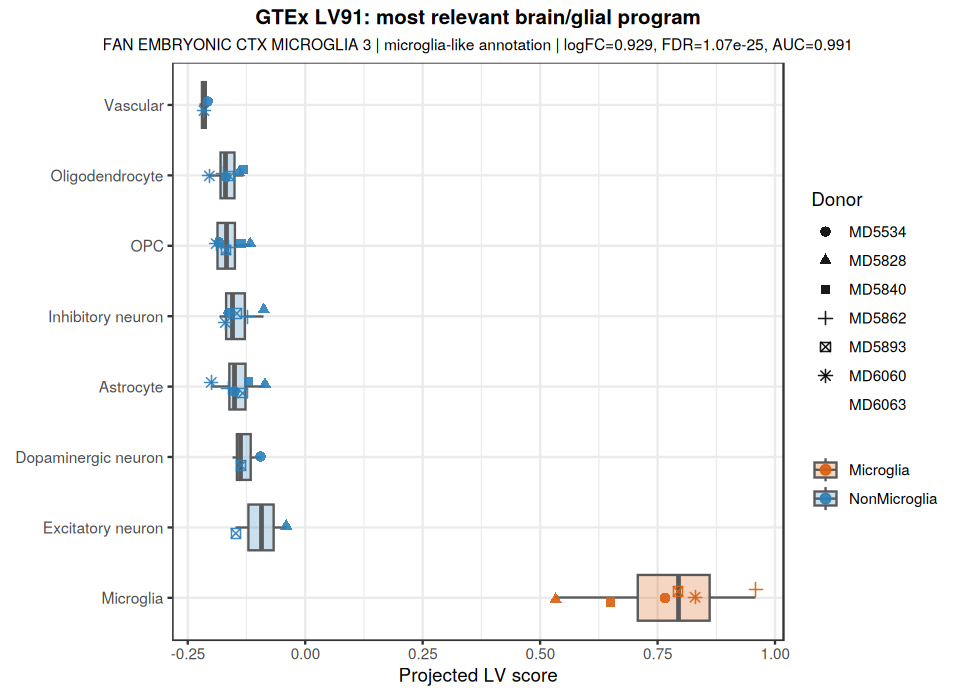

In [17]:
gtex_relevant_annotations <- as.data.frame(models$GTEx$summary) %>%
  dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC),
                pathway_clean = clean_pathway(pathway)) %>%
  dplyr::filter(FDR < PATHWAY_FDR_CUTOFF, AUC > PATHWAY_AUC_CUTOFF) %>%
  dplyr::filter(grepl(broad_gtex_pattern, pathway, ignore.case = TRUE) |
                  grepl(broad_gtex_pattern, pathway_clean, ignore.case = TRUE))

gtex_relevant_lvs <- ranked_lvs$GTEx %>%
  dplyr::inner_join(gtex_relevant_annotations, by = "LV", suffix = c("_projection", "_pathway")) %>%
  dplyr::mutate(
    selected_projected_lv = adj.P.Val < LV_FDR_CUTOFF & abs_logFC >= LV_LOGFC_CUTOFF,
    expected_microglia_enriched = logFC > 0,
    relevance_group = dplyr::case_when(
      grepl("MICROGLIA", pathway, ignore.case = TRUE) ~ "microglia-like annotation",
      grepl("MYELOID|MACROPHAGE|IMMUNE", pathway, ignore.case = TRUE) ~ "immune/myeloid annotation",
      grepl("GLIA|ASTRO|OLIGO", pathway, ignore.case = TRUE) ~ "glial annotation",
      grepl("BRAIN|CORTEX|PFC|NEURON", pathway, ignore.case = TRUE) ~ "brain/neural annotation",
      TRUE ~ "other broad annotation"
    ),
    relevance_rank = dplyr::case_when(
      relevance_group == "microglia-like annotation" ~ 1L,
      relevance_group == "immune/myeloid annotation" ~ 2L,
      relevance_group == "glial annotation" ~ 3L,
      relevance_group == "brain/neural annotation" ~ 4L,
      TRUE ~ 5L
    )
  ) %>%
  dplyr::arrange(
    !expected_microglia_enriched,
    !selected_projected_lv,
    adj.P.Val,
    relevance_rank,
    dplyr::desc(AUC),
    dplyr::desc(abs_logFC)
  )

write.csv(gtex_relevant_lvs,
          file.path(results_dir, "GTEx_brain_glial_relevant_LV_candidates.csv"),
          row.names = FALSE)

top_gtex_relevant <- if (nrow(gtex_relevant_lvs) == 0) data.frame() else gtex_relevant_lvs[1, , drop = FALSE]
top_gtex_lv <- if (nrow(top_gtex_relevant) == 0) NA_character_ else top_gtex_relevant$LV[1]
top_gtex_label <- if (nrow(top_gtex_relevant) == 0) {
  "No significant GTEx brain/glial annotation matched this contrast"
} else {
  paste0(clean_pathway(top_gtex_relevant$pathway[1]),
         " | ", top_gtex_relevant$relevance_group[1],
         " | logFC=", signif(top_gtex_relevant$logFC[1], 3),
         ", FDR=", signif(top_gtex_relevant$adj.P.Val[1], 3),
         ", AUC=", signif(top_gtex_relevant$AUC[1], 3))
}

options(repr.plot.width = 8, repr.plot.height = 5.8)
p_gtex_relevant <- make_lv_score_plot(
  B = B_list$GTEx,
  meta = meta_pb,
  lv = top_gtex_lv,
  model_name = "GTEx",
  lv_label = top_gtex_label,
  title = paste0("GTEx ", top_gtex_lv, ": most relevant brain/glial program")
)
print(p_gtex_relevant)
ggsave(file.path(figure_dir, "top_GTEx_brain_glial_LV_scores_by_cell_type.png"),
       plot = p_gtex_relevant, width = 8, height = 5.8, dpi = 150)

gtex_relevant_lvs %>%
  dplyr::select(LV, pathway, relevance_group, AUC, FDR, logFC, adj.P.Val,
                direction, selected_projected_lv, expected_microglia_enriched) %>%
  dplyr::slice_head(n = 20)

## Pathways inferred from selected shifted LVs

In [18]:
pathway_hits <- dplyr::bind_rows(lapply(names(models), function(model_name) {
  extract_shifted_pathways(ranked_lvs[[model_name]], models[[model_name]], model_name)
}))

pathway_summary <- summarise_shifted_pathways(pathway_hits)

for (model_name in names(models)) {
  write.csv(pathway_hits %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_LV_pathway_hits.csv")),
            row.names = FALSE)
  write.csv(pathway_summary %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_pathway_summary.csv")),
            row.names = FALSE)
}

cat("Annotated pathway hits:", nrow(pathway_hits), "
")
pathway_summary %>%
  dplyr::group_by(model, direction) %>%
  dplyr::summarise(n_pathways = dplyr::n_distinct(pathway_clean), .groups = "drop")

Annotated pathway hits: 155 


model,direction,n_pathways
<chr>,<chr>,<int>
ARCHS4,Higher in Microglia,29
ARCHS4,Higher in Non-microglia,19
GTEx,Higher in Microglia,53
GTEx,Higher in Non-microglia,47


### Pathway shift plots

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

for (model_name in names(models)) {
  p <- make_pathway_shift_plot(pathway_hits, model_name, top_n_per_direction = 12)
  print(p)
  ggsave(file.path(figure_dir, paste0("shifted_pathways_", model_name, ".png")),
         plot = p, width = 10, height = 8, dpi = 150)
}

## ARCHS4 vs GTEx pathway comparison

In [ ]:
collapse_model_pathways <- function(pathway_summary, model_name) {
  empty_model_paths <- data.frame(
    pathway_clean = character(), direction = character(), n_lvs = integer(),
    max_abs_logFC = numeric(), min_lv_FDR = numeric(),
    best_AUC = numeric(), LVs = character(), stringsAsFactors = FALSE
  )
  if (nrow(pathway_summary) == 0 || !model_name %in% pathway_summary$model) {
    return(empty_model_paths)
  }
  pathway_summary %>%
    dplyr::filter(model == model_name) %>%
    dplyr::group_by(pathway_clean) %>%
    dplyr::summarise(
      direction = paste(sort(unique(direction)), collapse = "; "),
      n_lvs = sum(n_lvs),
      max_abs_logFC = max(max_abs_logFC, na.rm = TRUE),
      min_lv_FDR = min(min_lv_FDR, na.rm = TRUE),
      best_AUC = max(best_AUC, na.rm = TRUE),
      LVs = paste(unique(LVs), collapse = ", "),
      .groups = "drop"
    )
}

archs4_paths <- collapse_model_pathways(pathway_summary, "ARCHS4") %>%
  dplyr::rename(ARCHS4_direction = direction, ARCHS4_n_lvs = n_lvs,
                ARCHS4_max_abs_logFC = max_abs_logFC, ARCHS4_min_lv_FDR = min_lv_FDR,
                ARCHS4_best_AUC = best_AUC, ARCHS4_LVs = LVs)

gtex_paths <- collapse_model_pathways(pathway_summary, "GTEx") %>%
  dplyr::rename(GTEx_direction = direction, GTEx_n_lvs = n_lvs,
                GTEx_max_abs_logFC = max_abs_logFC, GTEx_min_lv_FDR = min_lv_FDR,
                GTEx_best_AUC = best_AUC, GTEx_LVs = LVs)

comparison_tbl <- dplyr::full_join(archs4_paths, gtex_paths, by = "pathway_clean") %>%
  dplyr::mutate(
    shared = !is.na(ARCHS4_direction) & !is.na(GTEx_direction),
    direction_agreement = dplyr::case_when(
      !shared ~ "model-specific",
      ARCHS4_direction == GTEx_direction ~ "same",
      TRUE ~ "mixed or opposite"
    ),
    max_evidence = pmax(ARCHS4_max_abs_logFC, GTEx_max_abs_logFC, na.rm = TRUE)
  ) %>%
  dplyr::arrange(dplyr::desc(shared), direction_agreement,
                 dplyr::desc(max_evidence), pathway_clean)

write.csv(comparison_tbl,
          file.path(results_dir, "ARCHS4_GTEx_inferred_pathway_comparison.csv"),
          row.names = FALSE)

cat("ARCHS4 pathways:", nrow(archs4_paths), "\n")
cat("GTEx pathways:", nrow(gtex_paths), "\n")
cat("Shared pathways:", sum(comparison_tbl$shared), "\n")

comparison_tbl %>% dplyr::count(shared, direction_agreement)

## Interpretation

In [ ]:
archs4_directional_support <- nrow(top_archs4_microglia) > 0 &&
  isTRUE(top_archs4_microglia$expected_microglia_enriched[1]) &&
  isTRUE(top_archs4_microglia$adj.P.Val[1] < LV_FDR_CUTOFF)

archs4_selected_support <- archs4_directional_support &&
  isTRUE(top_archs4_microglia$abs_logFC[1] >= LV_LOGFC_CUTOFF)

gtex_exact_targets_present <- nrow(gtex_exact_target_check) > 0

# Determine annotation granularity of top ARCHS4 target
archs4_annotation_level <- if (nrow(top_archs4_microglia) == 0) {
  "unknown"
} else if (grepl("BIG.GROUP|MAJOR.TYPE", top_archs4_microglia$pathway_clean[1], ignore.case = TRUE)) {
  "broad population-level"
} else {
  "subtype-level"
}

# Determine annotation granularity of top GTEx candidate
gtex_annotation_level <- if (nrow(top_gtex_relevant) == 0) {
  "unknown"
} else if (grepl("[0-9]$", top_gtex_relevant$pathway[1])) {
  "subtype-level"
} else if (grepl("BIG.GROUP|MAJOR.TYPE", top_gtex_relevant$pathway[1], ignore.case = TRUE)) {
  "broad population-level"
} else {
  "category-level"
}

archs4_lfc_note <- if (nrow(top_archs4_microglia) == 0) {
  ""
} else if (archs4_selected_support) {
  " This passes both the LV FDR and absolute logFC filters."
} else if (archs4_directional_support) {
  paste0(
    " The effect size (logFC=", signif(top_archs4_microglia$logFC[1], 3),
    ") is small relative to the ", LV_LOGFC_CUTOFF, " cutoff, consistent with a ",
    archs4_annotation_level, " annotation: a BIG-GROUPS or MAJOR-TYPES microglia program",
    " captures shared microglia identity that is only moderately higher vs the mixed",
    " non-microglia pool compared to a narrower subtype-specific program."
  )
} else {
  " This does not pass the directional FDR support check."
}

archs4_text <- if (nrow(top_archs4_microglia) == 0) {
  "No ARCHS4 LV annotated with the two target microglia pathways was found in the loaded model summary."
} else {
  paste0(
    "The ARCHS4 target LV was ", top_archs4_microglia$LV[1],
    " annotated to ", top_archs4_microglia$pathway_clean[1],
    " (AUC=", signif(top_archs4_microglia$AUC[1], 3), ")",
    " with logFC=", signif(top_archs4_microglia$logFC[1], 3),
    " and FDR=", signif(top_archs4_microglia$adj.P.Val[1], 3), ".",
    archs4_lfc_note
  )
}

gtex_candidate_text <- if (nrow(top_gtex_relevant) == 0) {
  "No GTEx LV with a significant broad brain/glial/myeloid annotation was selected by the current candidate rules."
} else {
  paste0(
    "The best-matched GTEx candidate was ", top_gtex_relevant$LV[1],
    " annotated to ", clean_pathway(top_gtex_relevant$pathway[1]),
    " (", top_gtex_relevant$relevance_group[1], "; ", gtex_annotation_level, ")",
    " with logFC=", signif(top_gtex_relevant$logFC[1], 3),
    " and FDR=", signif(top_gtex_relevant$adj.P.Val[1], 3), ".",
    " A numeric suffix in the annotation (e.g., MICROGLIA_3) indicates a specific",
    " microglia subtype rather than the canonical microglia cell class:",
    " this subtype may be particularly enriched in the substantia nigra context,",
    " explaining the larger logFC compared to the ARCHS4 broad-class annotation."
  )
}

exact_annotation_text <- paste0(
  "GTEx exact target annotations present: ", gtex_exact_targets_present, ".",
  if (!gtex_exact_targets_present) {
    paste0(
      " The two ARCHS4 target pathways (C8_FAN_EMBRYONIC_CTX_BIG_GROUPS_MICROGLIA and",
      " C8_ZHONG_PFC_MAJOR_TYPES_MICROGLIA) are absent from the GTEx model annotation",
      " vocabulary: confirming ARCHS4-specific coverage of the BIG-GROUPS and MAJOR-TYPES",
      " level microglia cell-state taxonomy."
    )
  } else ""
)

summary_sentence <- if (archs4_directional_support && !gtex_exact_targets_present) {
  paste0(
    "Overall: ARCHS4 uniquely encodes the broad population-level microglia programs",
    " (BIG_GROUPS, MAJOR_TYPES) as explicit annotation vocabulary, and the corresponding",
    " ARCHS4 LV is significantly enriched in microglia (FDR < 1e-15).",
    " GTEx does not contain these exact annotations but does contain a finer",
    " subtype-level microglia annotation (", clean_pathway(top_gtex_relevant$pathway[1]), ")",
    " that is more strongly enriched in this substantia nigra dataset.",
    " This should be read as complementary coverage at different annotation granularities,",
    " not as evidence that GTEx lacks microglia signal.",
    " ARCHS4 provides the conceptually cleaner microglia identity annotation,",
    " while GTEx resolves finer subtype structure that may be region-specific."
  )
} else if (!gtex_exact_targets_present) {
  paste0(
    "Overall: The exact target annotations are ARCHS4-specific,",
    " but the ARCHS4 target LV did not pass both FDR and logFC thresholds in this run.",
    " GTEx may capture related microglia or brain programs through its own annotation vocabulary."
  )
} else {
  "Overall: Both models contain exact target annotations in this run; the comparison reflects projection-strength rather than annotation-specificity."
}

interpretation <- c(archs4_text, exact_annotation_text, gtex_candidate_text, summary_sentence)
writeLines(interpretation)
writeLines(interpretation, file.path(results_dir, "interpretation.txt"))

## Export for figures

In [ ]:
panel_dir <- here("output", "03_model_biology", "00_archs4", "03_tissue_projections", "04_human_brain_microglia_GSE126836")
dir.create(panel_dir, recursive = TRUE, showWarnings = FALSE)

write.csv(pathway_summary %>% dplyr::filter(model == "ARCHS4"),
          file.path(panel_dir, "microglia_archs4_pathway_summary.csv"), row.names = FALSE)
write.csv(pathway_summary %>% dplyr::filter(model == "GTEx"),
          file.path(panel_dir, "microglia_gtex_pathway_summary.csv"), row.names = FALSE)
write.csv(comparison_tbl,
          file.path(panel_dir, "microglia_pathway_comparison.csv"), row.names = FALSE)
write.csv(pathway_hits %>% dplyr::filter(model == "ARCHS4"),
          file.path(panel_dir, "microglia_archs4_lv_pathway_hits.csv"), row.names = FALSE)
write.csv(pathway_hits %>% dplyr::filter(model == "GTEx"),
          file.path(panel_dir, "microglia_gtex_lv_pathway_hits.csv"), row.names = FALSE)
write.csv(target_archs4_microglia_hits,
          file.path(panel_dir, "microglia_archs4_target_lv_hits.csv"), row.names = FALSE)
write.csv(gtex_relevant_lvs,
          file.path(panel_dir, "microglia_gtex_relevant_lv_candidates.csv"), row.names = FALSE)

for (fig_file in list.files(figure_dir, pattern = "\\.png$", full.names = TRUE)) {
  file.copy(fig_file, file.path(panel_dir, basename(fig_file)), overwrite = TRUE)
}

message("Exported microglia data to ", panel_dir)